# fio DFS All-Patterns Analysis

Analyzes `rand_write / rand_read / mixed` and `seq_write / seq_read / mixed` results
across block sizes for a single configuration:

- **nj16/iod16**: numjobs=16, iodepth=16 (256 total outstanding I/Os)

The `prefill` job is excluded from all analysis.

In [1]:
import json, glob, os

_files = sorted(glob.glob("*.json"))
with open(_files[0]) as _f:
    _ref = json.load(_f)
_g = _ref["global options"]

print("=== Workload Design ===")
print(f"  Engine         : {_g['ioengine']} (DAOS DFS via libfio)")
print(f"  numjobs        : {_g['numjobs']}   iodepth: {_g['iodepth']}  → {int(_g['numjobs'])*int(_g['iodepth'])} total outstanding I/Os")
print(f"  File size      : {_g['size']}/job × {_g['numjobs']} jobs = {int(_g['size'].rstrip('g'))*int(_g['numjobs'])} GiB working set")
print(f"  Runtime/section: {_g['runtime']} s  (time_based={_g['time_based']}, direct={_g['direct']})")
print(f"  Block sizes    : 4k / 16k / 1m / 2m / 4m  (one per JSON file)")
print()
print("  Sections (stonewall-separated, in order):")
for _job in _ref["jobs"]:
    _opts = _job.get("job options", {})
    _rw   = _opts.get("rw", "")
    _mix  = f"  rwmixwrite={_opts['rwmixwrite']}%" if "rwmixwrite" in _opts else \
            f"  rwmixread={_opts['rwmixread']}%"  if "rwmixread"  in _opts else ""
    _note = "  [fills file, no time_based]" if _opts.get("time_based") == "0" else ""
    print(f"    {_job['jobname']:14s}  rw={_rw}{_mix}{_note}")

print("\n=== Cross-file Consistency Check ===")
_SKIP = {"bs", "cont"}
_ref_jobs   = [(_j["jobname"], _j.get("job options", {})) for _j in _ref["jobs"]]
_ref_global = {k: v for k, v in _g.items() if k not in _SKIP}
_bs_counts, _diffs = {}, []
for _fp in _files:
    with open(_fp) as _f:
        _d = json.load(_f)
    _gg = {k: v for k, v in _d["global options"].items() if k not in _SKIP}
    _bs = _d["global options"]["bs"]
    _bs_counts[_bs] = _bs_counts.get(_bs, 0) + 1
    _jobs = [(_j["jobname"], _j.get("job options", {})) for _j in _d["jobs"]]
    if _gg != _ref_global or _jobs != _ref_jobs:
        _diffs.append(os.path.basename(_fp))

print(f"  Files checked : {len(_files)}")
print(f"  Block sizes   : { {k: v for k, v in sorted(_bs_counts.items())} }")
if _diffs:
    print(f"  INCONSISTENT  : {_diffs}")
else:
    print("  Result        : ALL files share identical global options and job structure ✓")


=== Workload Design ===
  Engine         : dfs (DAOS DFS via libfio)
  numjobs        : 16   iodepth: 16  → 256 total outstanding I/Os
  File size      : 20g/job × 16 jobs = 320 GiB working set
  Runtime/section: 60 s  (time_based=1, direct=1)
  Block sizes    : 4k / 16k / 1m / 2m / 4m  (one per JSON file)

  Sections (stonewall-separated, in order):
    prefill         rw=write  [fills file, no time_based]
    rand_write      rw=randwrite
    rand_read       rw=randread
    rand_readH      rw=randrw  rwmixwrite=20%
    rand_readB      rw=randrw  rwmixread=50%
    rand_writeH     rw=randrw  rwmixwrite=80%
    seq_write       rw=write
    seq_read        rw=read
    seq_readH       rw=readwrite  rwmixwrite=20%
    seq_readB       rw=readwrite  rwmixread=50%
    seq_writeH      rw=readwrite  rwmixwrite=80%

=== Cross-file Consistency Check ===
  Files checked : 53
  Block sizes   : {'16k': 11, '1m': 10, '2m': 10, '4k': 11, '4m': 11}
  Result        : ALL files share identical global opti

In [2]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [3]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        try:
            d = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping invalid/empty JSON: {Path(fpath).name}")
            return []

    rows = []
    for job in d["jobs"]:
        name = job["jobname"]
        if name == "prefill":
            continue

        def ms(v): return v / 1e6

        if "mixed" in job:
            mx = job["mixed"]
            bw_GiBs     = mx["bw"] / 1024 / 1024
            iops        = mx["iops"]
            lat_max_ms  = ms(mx["lat_ns"]["max"])
            lat_mean_ms = ms(mx["lat_ns"]["mean"])
        else:
            r = job["read"]
            w = job["write"]
            has_read  = r["total_ios"] > 0
            has_write = w["total_ios"] > 0

            bw_GiBs = (r["bw"] * has_read + w["bw"] * has_write) / 1024 / 1024
            iops    =  r["iops"] * has_read + w["iops"] * has_write

            candidates = []
            if has_read:  candidates.append(r["lat_ns"]["max"])
            if has_write: candidates.append(w["lat_ns"]["max"])
            lat_max_ms = ms(max(candidates)) if candidates else 0

            mean_num = (r["lat_ns"]["mean"] * r["total_ios"] * has_read +
                        w["lat_ns"]["mean"] * w["total_ios"] * has_write)
            mean_den = r["total_ios"] * has_read + w["total_ios"] * has_write
            lat_mean_ms = ms(mean_num / mean_den) if mean_den > 0 else 0

        rows.append(dict(
            block_size  = bs,
            numjobs     = nj,
            iodepth     = iod,
            config      = f"nj{nj}/iod{iod}",
            pattern     = name,
            bw_GiBs     = bw_GiBs,
            iops        = iops,
            lat_mean_ms = lat_mean_ms,
            lat_max_ms  = lat_max_ms,
        ))
    return rows


all_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    all_rows.extend(parse_file(fpath))

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
PATTERN_ORDER = [
    "rand_read", "rand_readH", "rand_readB", "rand_writeH", "rand_write",
    "seq_read",  "seq_readH",  "seq_readB",  "seq_writeH", "seq_write"
]
CONFIGS = ["nj16/iod16"]

df = pd.DataFrame(all_rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df["pattern"]    = pd.Categorical(df["pattern"],    categories=PATTERN_ORDER, ordered=True)
df = df.sort_values(["config", "block_size", "pattern"]).reset_index(drop=True)

print(f"Loaded {len(df)} jobs from {df['config'].nunique()} config(s) × {df['block_size'].nunique()} block size(s)")
for cfg in CONFIGS:
    n = len(df[df["config"] == cfg])
    print(f"  {cfg}: {n} jobs")
df

Loaded 530 jobs from 1 config(s) × 5 block size(s)
  nj16/iod16: 530 jobs


,block_size,numjobs,iodepth,config,pattern,bw_GiBs,iops,lat_mean_ms,lat_max_ms
0,4k,16,16,nj16/iod16,rand_read,0.570689,149602.865711,1.709775,98.078022
1,4k,16,16,nj16/iod16,rand_read,0.535130,140281.077118,1.823537,93.698270
2,4k,16,16,nj16/iod16,rand_read,0.518213,135846.633229,1.883213,102.689690
3,4k,16,16,nj16/iod16,rand_read,0.520593,136470.400053,1.874469,111.305953
4,4k,16,16,nj16/iod16,rand_read,0.516359,135360.749159,1.889916,108.638763
...,...,...,...,...,...,...,...,...,...
525,4m,16,16,nj16/iod16,seq_write,22.191637,5681.059307,44.658610,233.747044
526,4m,16,16,nj16/iod16,seq_write,22.864742,5853.374192,43.343767,234.601302
527,4m,16,16,nj16/iod16,seq_write,22.479504,5754.753105,44.084686,219.492735
528,4m,16,16,nj16/iod16,seq_write,22.285412,5705.065441,44.481356,210.949645


In [4]:
def plot_metric(ax, col, cfg):
    """Plot `col` vs operation type; one line per (access, block_size) combo.

    Returns (x_tick_positions, line_handles).
    x_tick_positions is a list of ints 0..4, one per op type
    (rand_read/seq_read → 0, ..., rand_write/seq_write → 4).
    """
    OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
    ACCESSES    = ["rand", "seq"]
    LS          = {"rand": "-", "seq": "--"}
    colors      = plt.cm.tab10.colors

    df_cfg = df[df["config"] == cfg]
    x      = list(range(len(OP_SUFFIXES)))
    lines  = []

    for i, bs in enumerate(BS_ORDER):
        if bs not in df_cfg["block_size"].values:
            continue
        df_bs = df_cfg[df_cfg["block_size"] == bs]
        for acc in ACCESSES:
            vals = [
                df_bs[df_bs["pattern"] == f"{acc}_{op}"][col].median()
                for op in OP_SUFFIXES
            ]
            ln, = ax.plot(x, vals, linestyle=LS[acc], color=colors[i],
                          marker="o", markersize=4, label=f"{acc}/{bs}")
            lines.append(ln)

    return x, lines


## Run Count Summary (nj16/iod16)

In [5]:

# Run count per (pattern × block_size) — nj16/iod16 only
df16 = df[df["config"] == "nj16/iod16"]
run_counts = (
    df16.groupby(["pattern", "block_size"], observed=True)
    .size()
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(run_counts.style
    .set_caption("Number of runs per pattern × block size (nj16/iod16)")
    .format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,11,11,10,10,11
rand_readH,11,11,10,10,11
rand_readB,11,11,10,10,11
rand_writeH,11,11,10,10,11
rand_write,11,11,10,10,11
seq_read,11,11,10,10,11
seq_readH,11,11,10,10,11
seq_readB,11,11,10,10,11
seq_writeH,11,11,10,10,11


## Run-to-Run Variability (nj16/iod16)

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_61896/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_61896/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_61896/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/fo

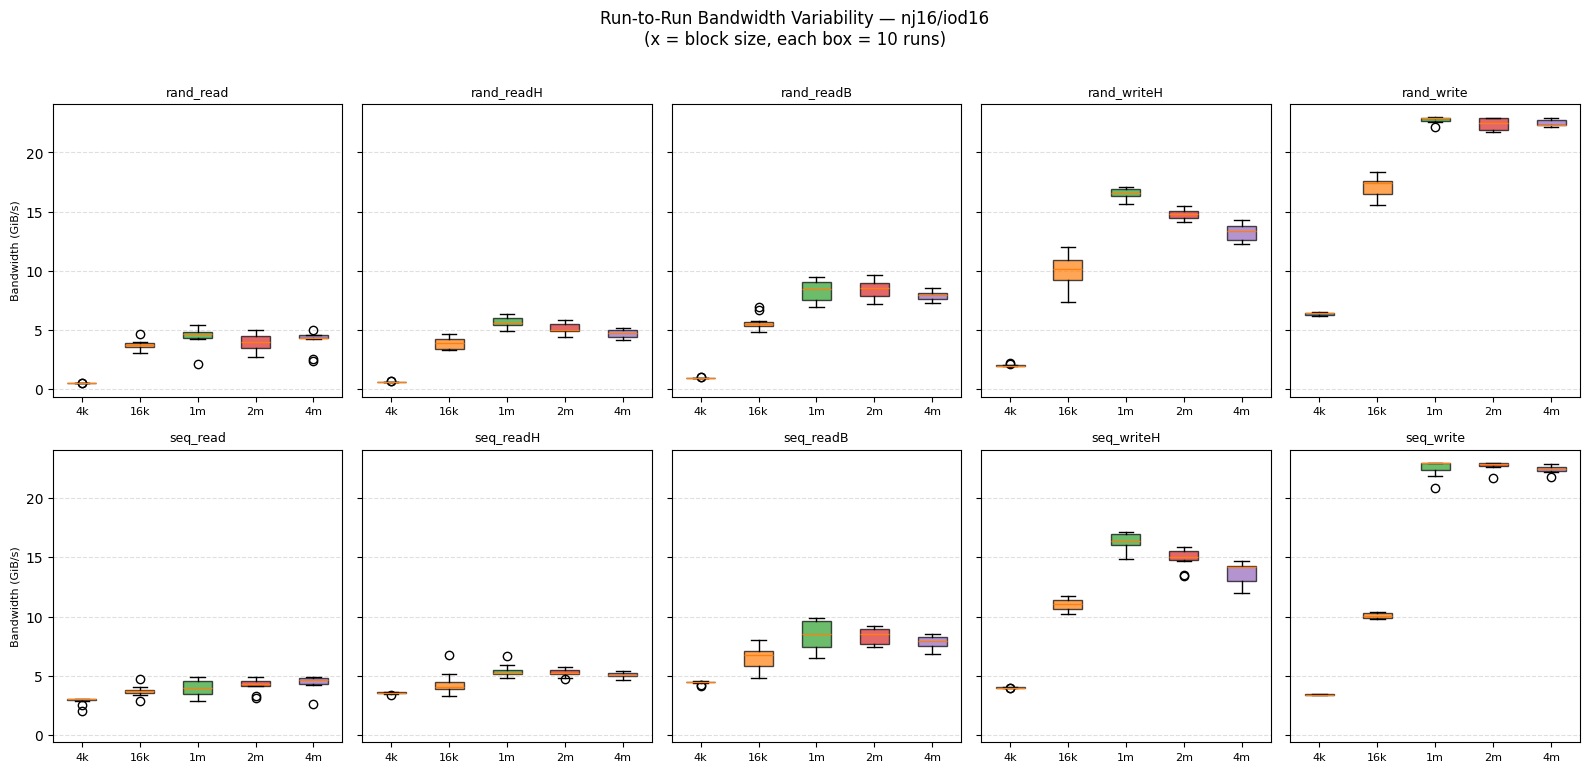

In [6]:

# Run-to-run bandwidth variability — nj16/iod16 only
# One subplot per pattern; x-axis = block sizes; shared y-axis
df16 = df[df["config"] == "nj16/iod16"]
bs_present  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
pat_present = [p for p in PATTERN_ORDER if p in df16["pattern"].unique()]

n_pat = len(pat_present)
ncols = 5
nrows = (n_pat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.8),
                         sharey=True, squeeze=False)

clrs = plt.cm.tab10.colors

for idx, pat in enumerate(pat_present):
    ax = axes[idx // ncols][idx % ncols]
    data_per_bs = [
        df16.loc[(df16["pattern"] == pat) & (df16["block_size"] == bs), "bw_GiBs"].values
        for bs in bs_present
    ]
    bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
    for patch, clr in zip(bp["boxes"], clrs[:len(bs_present)]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax.set_title(pat, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Bandwidth (GiB/s)", fontsize=8)

# Hide unused axes
for idx in range(n_pat, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle("Run-to-Run Bandwidth Variability — nj16/iod16\n(x = block size, each box = 10 runs)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "variability_boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [7]:

# CV% (std/mean × 100) for each pattern × block size — nj16/iod16
df16 = df[df["config"] == "nj16/iod16"]
cv_pivot = (
    df16.groupby(["pattern", "block_size"], observed=True)["bw_GiBs"]
    .agg(lambda x: x.std() / x.mean() * 100)
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(cv_pivot.style
    .set_caption("Coefficient of Variation (%) of bandwidth — nj16/iod16")
    .format("{:.1f}%")
    .background_gradient(cmap="YlOrRd", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,4.5%,11.4%,19.6%,18.3%,20.6%
rand_readH,4.5%,13.5%,8.1%,8.5%,8.1%
rand_readB,4.1%,10.9%,10.5%,10.3%,5.1%
rand_writeH,3.5%,13.6%,3.2%,3.1%,5.5%
rand_write,1.8%,4.9%,1.2%,2.4%,1.2%
seq_read,11.3%,11.9%,17.7%,13.6%,14.5%
seq_readH,2.2%,21.7%,9.9%,5.9%,4.5%
seq_readB,3.2%,14.7%,15.2%,8.4%,6.8%
seq_writeH,0.4%,4.6%,4.3%,5.7%,6.6%


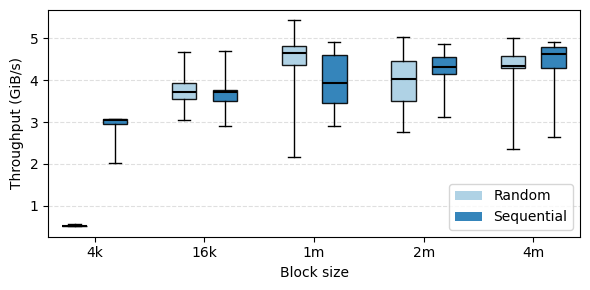

In [8]:

# Boxplot: rand_read vs seq_read — all block sizes — nj16/iod16 (publication figure)
from matplotlib.patches import Patch

ALL_BS  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
ACCESS  = ["rand", "seq"]
C_RAND  = "#a6cee3"   # Paired light-blue
C_SEQ   = "#1f78b4"   # Paired dark-blue
GAP     = 0.7

fig, ax = plt.subplots(figsize=(6, 3))

positions, data, colors, group_centers = [], [], [], []
for g, bs in enumerate(ALL_BS):
    base = g * (len(ACCESS) + GAP)
    group_centers.append(base + 0.5)
    for acc, c in zip(ACCESS, [C_RAND, C_SEQ]):
        positions.append(base + ACCESS.index(acc))
        data.append(df16.loc[
            (df16["pattern"] == f"{acc}_read") & (df16["block_size"] == bs), "bw_GiBs"
        ].values)
        colors.append(c)

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6,
                whis=(0, 100), showfliers=False,
                medianprops=dict(color="black", linewidth=1.5))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)

ax.set_xticks(group_centers)
ax.set_xticklabels(ALL_BS, fontsize=10)
ax.set_xlabel("Block size", fontsize=10)
ax.set_ylabel("Throughput (GiB/s)", fontsize=10)
ax.set_xlim(positions[0] - 0.65, positions[-1] + 0.65)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend(handles=[
    Patch(facecolor=C_RAND, alpha=0.9, label="Random"),
    Patch(facecolor=C_SEQ,  alpha=0.9, label="Sequential"),
], fontsize=10, loc="lower right")

# ax.set_title("Read-only Bandwidth Distribution (nj16/iod16, 10 runs each)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-read-boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Actual Data Volume Transferred

Calculated from `io_bytes` in the fio JSON output (exact bytes, not BW × time).
Mixed patterns use `unified_rw_reporting=1` so only a combined total is available;
read/write split applies the nominal ratios (`readH`=80/20, `readB`=50/50, `writeH`=20/80).
Working set is 20 GiB/job × 16 jobs = **320 GiB**; each timed section runs 60 s.

In [9]:
# Nominal read fraction per pattern (mixed patterns: unified_rw_reporting combines R+W)
READ_FRAC = {
    "rand_read":   1.0,  "seq_read":   1.0,
    "rand_readH":  0.8,  "seq_readH":  0.8,
    "rand_readB":  0.5,  "seq_readB":  0.5,
    "rand_writeH": 0.2,  "seq_writeH": 0.2,
    "rand_write":  0.0,  "seq_write":  0.0,
}

vol_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    if not m:
        continue
    bs = m.group(1)
    try:
        with open(fpath) as f:
            d = json.load(f)
    except Exception:
        continue

    for job in d["jobs"]:
        name = job["jobname"]
        if name not in READ_FRAC:
            continue
        if "mixed" in job:
            total_b   = job["mixed"]["io_bytes"]
            rf        = READ_FRAC[name]
            read_GiB  = total_b * rf       / 1024**3
            write_GiB = total_b * (1 - rf) / 1024**3
        else:
            read_GiB  = job["read"]["io_bytes"]  / 1024**3
            write_GiB = job["write"]["io_bytes"] / 1024**3

        vol_rows.append(dict(
            block_size=bs, pattern=name,
            read_GiB=read_GiB, write_GiB=write_GiB,
        ))

df_vol = pd.DataFrame(vol_rows)
df_vol["block_size"] = pd.Categorical(df_vol["block_size"], categories=BS_ORDER, ordered=True)
df_vol["pattern"]    = pd.Categorical(df_vol["pattern"],    categories=PATTERN_ORDER, ordered=True)

# ── Table 1: per-pattern × per-block-size (median across repeated runs) ──────
med_vol = (
    df_vol.groupby(["pattern", "block_size"], observed=True)[["read_GiB", "write_GiB"]]
    .median()
    .unstack("block_size")
)
med_vol.columns = pd.MultiIndex.from_tuples(
    [(col, bs) for col, bs in med_vol.columns], names=["metric", "block_size"]
)
col_order = [(metric, bs) for metric in ["read_GiB", "write_GiB"]
             for bs in BS_ORDER if (metric, bs) in med_vol.columns]
med_vol = med_vol.reindex(PATTERN_ORDER)[col_order]

display(med_vol.style
    .set_caption("Data transferred per section per run — GiB  (median over repeated runs)")
    .format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None)
)


# ── Grand summary ─────────────────────────────────────────────────────────────
ro_per_section = (
    df_vol[df_vol["pattern"].isin(["rand_read", "seq_read"])]
    .groupby(["pattern", "block_size"], observed=True)["read_GiB"]
    .median()
    .mean()
)
print(f"\nRead-only sections average {ro_per_section:.0f} GiB per 60 s section"
      f" (working set = 320 GiB → {ro_per_section/320*100:.0f}% of one full pass).")



Read-only sections average 222 GiB per 60 s section (working set = 320 GiB → 69% of one full pass).


## Mean/Max Latency (ms)

In [10]:
pivot = (
    df[df["config"] == "nj16/iod16"]
    .pivot_table(index="pattern", columns="block_size", values="lat_mean_ms",
                 aggfunc="median", observed=True)
    .reindex(index=[p for p in PATTERN_ORDER if p in df["pattern"].unique()],
             columns=[b for b in BS_ORDER if b in df["block_size"].unique()])
)
display(pivot.round(3).style
    .set_caption("Median Mean Latency (ms) — nj16/iod16")
    .format("{:.3f}")
    .background_gradient(cmap="YlOrRd", axis=None)
)

block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,1.883,1.052,53.633,123.850,229.257
rand_readH,1.529,1.000,44.780,99.636,210.096
rand_readB,1.011,0.702,29.359,58.027,125.219
rand_writeH,0.485,0.381,15.006,33.601,74.545
rand_write,0.152,0.223,10.821,22.055,44.353
seq_read,0.321,1.049,63.522,115.621,215.355
seq_readH,0.273,0.973,47.731,94.621,198.156
seq_readB,0.217,0.575,29.345,58.527,126.282
seq_writeH,0.243,0.351,15.197,33.105,70.041


## Bandwidth (GiB/s)

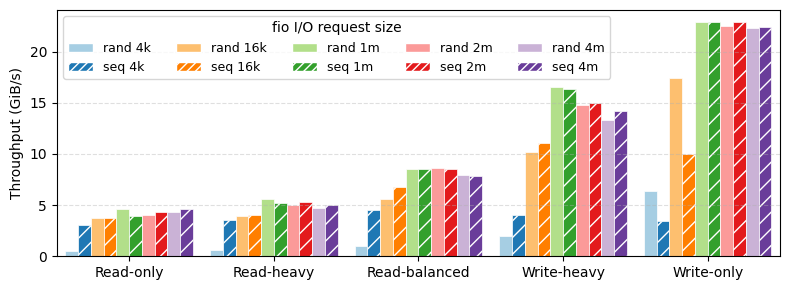

In [11]:
from matplotlib.patches import Patch

OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
OP_LABELS   = ["Read-only", "Read-heavy", "Read-balanced", "Write-heavy", "Write-only"]

df16       = df[df["config"] == "nj16/iod16"]
bs_present = [b for b in BS_ORDER if b in df16["block_size"].values]
n_bs       = len(bs_present)   # 5
n_ops      = len(OP_SUFFIXES)  # 5

# Paired cmap: even index = light (rand), odd = dark (seq)
# Block-size → hue:  4k=blue(0,1)  16k=orange(6,7)  1m=green(2,3)  2m=red(4,5)  4m=purple(8,9)
_p          = [plt.cm.Paired(i / 12) for i in range(12)]
PAIR_START  = [0, 6, 2, 4, 8]          # light-color index per bs in bs_present order
rand_colors = [_p[k]     for k in PAIR_START]
seq_colors  = [_p[k + 1] for k in PAIR_START]

bar_w   = 0.075
pair_w  = 2 * bar_w                    # rand bar | seq bar, no intra-pair gap
group_w = n_bs * pair_w + 0.10         # pair cluster + inter-group gap
x_base  = np.arange(n_ops) * group_w

fig, ax = plt.subplots(figsize=(8, 3))

for i, bs in enumerate(bs_present):
    pair_center = (i - (n_bs - 1) / 2) * pair_w
    for j, (acc, color, is_seq) in enumerate([
        ("rand", rand_colors[i], False),
        ("seq",  seq_colors[i],  True),
    ]):
        bar_x   = x_base + pair_center + (j - 0.5) * bar_w
        df_sub  = df16[df16["block_size"] == bs]
        medians = np.array([
            df_sub[df_sub["pattern"] == f"{acc}_{op}"]["bw_GiBs"].median()
            for op in OP_SUFFIXES
        ])
        ax.bar(bar_x, medians, width=bar_w, color=color,
               hatch="//" if is_seq else "",
               edgecolor="white", linewidth=0.5)

ax.set_xticks(x_base)
ax.set_xticklabels(OP_LABELS, fontsize=10)
ax.set_ylabel("Throughput (GiB/s)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xlim(x_base[0] - group_w * 0.5, x_base[-1] + group_w * 0.5)

# 2-column legend: col-0 = Random (solid), col-1 = Sequential (hatched)
# Interleave handles so ncol=2 fills: [rand_hdr, seq_hdr, rand_4k, seq_4k, ...]
rand_patches = [Patch(facecolor=rand_colors[i], edgecolor="white", label=f"rand {bs}")
                for i, bs in enumerate(bs_present)]
seq_patches  = [Patch(facecolor=seq_colors[i], edgecolor="white", hatch="////", label=f"seq {bs}")
                for i, bs in enumerate(bs_present)]
legend_handles = [h for pair in zip(rand_patches, seq_patches) for h in pair]
ax.legend(handles=legend_handles,
          title="fio I/O request size",
          fontsize=9, loc="upper left", ncol=5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-bw-all-pattern-nj16-iod16.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
OP_LABEL_MAP = {
    "read":   "Read-only",
    "readH":  "Read-heavy",
    "readB":  "Read-balanced",
    "writeH": "Write-heavy",
    "write":  "Write-only",
}

med = (
    df[df["config"] == "nj16/iod16"]
    .groupby(["block_size", "pattern"], observed=True)["bw_GiBs"]
    .median()
    .reset_index()
)

rows = []
for bs in BS_ORDER:
    if bs not in med["block_size"].values:
        continue
    for op in OP_SUFFIXES:
        rand_row = med[(med["block_size"] == bs) & (med["pattern"] == f"rand_{op}")]
        seq_row  = med[(med["block_size"] == bs) & (med["pattern"] == f"seq_{op}")]
        if rand_row.empty or seq_row.empty:
            continue
        r_bw = rand_row["bw_GiBs"].values[0]
        s_bw = seq_row["bw_GiBs"].values[0]
        rows.append(dict(
            workload    = OP_LABEL_MAP[op],
            block_size  = bs,
            rand_GiBs   = r_bw,
            seq_GiBs    = s_bw,
            rand_vs_seq = (r_bw / s_bw - 1) * 100,
        ))

comp = pd.DataFrame(rows)
comp["block_size"] = pd.Categorical(comp["block_size"], categories=BS_ORDER, ordered=True)
workload_order = [OP_LABEL_MAP[op] for op in OP_SUFFIXES]
bs_present = [b for b in BS_ORDER if b in comp["block_size"].cat.categories and
              b in comp["block_size"].values]

# Detailed table: rand bw, seq bw, ratio
detail = comp.set_index(["workload", "block_size"])[["rand_GiBs", "seq_GiBs", "rand_vs_seq"]]
detail = detail.unstack("block_size").reindex(workload_order, level=0)
detail.columns = pd.MultiIndex.from_tuples(
    [(metric, bs) for metric, bs in detail.columns],
    names=["metric", "block_size"]
)
col_order = [(m, b) for m in ["rand_GiBs", "seq_GiBs", "rand_vs_seq"] for b in bs_present
             if (m, b) in detail.columns]
detail = detail[col_order]

display(detail.style
    .set_caption(
        "Random vs Sequential — median bandwidth (GiB/s) and ratio [nj16/iod16]\n"
        "rand_vs_seq = (rand / seq − 1) × 100%; positive = random faster"
    )
    .format(lambda v: f"{v:.2f}", subset=[c for c in detail.columns if "rand_vs_seq" not in c[0]])
    .format(lambda v: f"{v:+.1f}%", subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
    .background_gradient(cmap="RdYlGn", axis=None,
                         subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
)

# Compact ratio-only pivot
pivot = (
    comp.pivot(index="workload", columns="block_size", values="rand_vs_seq")
    .reindex(index=workload_order, columns=bs_present)
)
display(pivot.style
    .set_caption("rand_vs_seq (%) summary — nj16/iod16  [positive = random faster]")
    .format("{:+.1f}%")
    .background_gradient(cmap="RdYlGn", axis=None)
)

block_size,4k,16k,1m,2m,4m
workload,,,,,
Read-only,-83.0%,-0.3%,+18.2%,-6.7%,-6.1%
Read-heavy,-82.1%,-2.7%,+6.7%,-5.0%,-5.7%
Read-balanced,-78.6%,-18.0%,-0.1%,+0.9%,+0.8%
Write-heavy,-49.8%,-8.0%,+1.3%,-1.5%,-6.0%
Write-only,+87.6%,+73.2%,+0.1%,-1.8%,-0.4%


## Summary Table: Median Bandwidth and CV% per Configuration

In [13]:

df16 = df[df["config"] == "nj16/iod16"]
bs_present  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
pat_present = [p for p in PATTERN_ORDER if p in df16["pattern"].unique()]

grp    = df16.groupby(["pattern", "block_size"], observed=True)["bw_GiBs"]
med_bw = grp.median().unstack("block_size").reindex(index=pat_present, columns=bs_present)
cv_pct = grp.agg(lambda x: x.std() / x.mean() * 100).unstack("block_size").reindex(index=pat_present, columns=bs_present)

combined = pd.concat({"Median BW (GiB/s)": med_bw, "CV (%)": cv_pct}, axis=1)
combined = combined.swaplevel(axis=1)
col_order = [(bs, m) for bs in bs_present for m in ["Median BW (GiB/s)", "CV (%)"]]
combined  = combined[col_order]

bw_cols = [c for c in combined.columns if c[1] == "Median BW (GiB/s)"]
cv_cols = [c for c in combined.columns if c[1] == "CV (%)"]

display(combined.style
    .set_caption("Median Bandwidth (GiB/s) and CV% per pattern × block size — nj16/iod16")
    .format("{:.2f}", subset=bw_cols)
    .format("{:.1f}%", subset=cv_cols)
    .background_gradient(cmap="Blues",   axis=None, subset=bw_cols)
    .background_gradient(cmap="YlOrRd",  axis=None, subset=cv_cols)
)


## bs=4k: Sequential vs Random Comparison

In [14]:

OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
OP_LABELS   = {
    "read":    "Read-only",
    "readH":   "Read-heavy (80R/20W)",
    "readB":   "Balanced (50R/50W)",
    "writeH":  "Write-heavy (20R/80W)",
    "write":   "Write-only",
}

df4k = df[(df["config"] == "nj16/iod16") & (df["block_size"] == "4k")]

def stats(acc, op):
    s = df4k[df4k["pattern"] == f"{acc}_{op}"]["bw_GiBs"]
    return s.median(), s.std() / s.mean() * 100

rows = []
for op in OP_SUFFIXES:
    rand_med, rand_cv = stats("rand", op)
    seq_med,  seq_cv  = stats("seq",  op)
    rows.append({
        "R/W mix":           OP_LABELS[op],
        ("Random",  "Median BW (GiB/s)"): rand_med,
        ("Random",  "CV (%)"):            rand_cv,
        ("Sequential", "Median BW (GiB/s)"): seq_med,
        ("Sequential", "CV (%)"):            seq_cv,
        ("Seq / Rand", "BW ratio"):       seq_med / rand_med,
    })

tbl = pd.DataFrame(rows).set_index("R/W mix")
tbl.columns = pd.MultiIndex.from_tuples(tbl.columns)

bw_cols    = [c for c in tbl.columns if c[1] == "Median BW (GiB/s)"]
cv_cols    = [c for c in tbl.columns if c[1] == "CV (%)"]
ratio_cols = [c for c in tbl.columns if c[1] == "BW ratio"]

display(tbl.style
    .set_caption("bs=4k — Sequential vs Random: median bandwidth and run-to-run variability (nj16/iod16)")
    .format("{:.3f}", subset=bw_cols)
    .format("{:.1f}%", subset=cv_cols)
    .format("{:.2f}×", subset=ratio_cols)
    .background_gradient(cmap="Blues",  axis=0, subset=bw_cols)
    .background_gradient(cmap="YlOrRd", axis=0, subset=cv_cols)
    .background_gradient(cmap="RdYlGn", axis=0, subset=ratio_cols)
)
